In [39]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [40]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots
from spectral_lines import LINES, print_available_lines

#  Data

In [41]:
cfg = LINES["SIII_9069"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [42]:
print(plot_label_line)
print(rest_wavelength)
print(wavelength_id)
print(element)
print(ion)
print(transition_id)

[S III]$\ \lambda$9069
9069.1
9069
S
S_III
S_III-9069


In [43]:
#line        = r'H$\alpha$'
#lambda_rest = 6562.8
#line_id     = 'H'
#line_id2   = "6563"

In [44]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)


LVM-30Dor-9069
LVM-30Dor-S-X


In [45]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [46]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [47]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [48]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


In [49]:

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)

radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


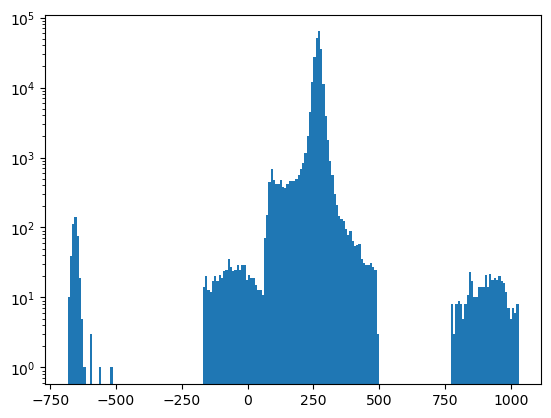

In [50]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [53]:
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) & (line_rad["log_F"] > 100)  & (line_rad["sigma"] < 1.5) 
line_mask = line_rad[mask]

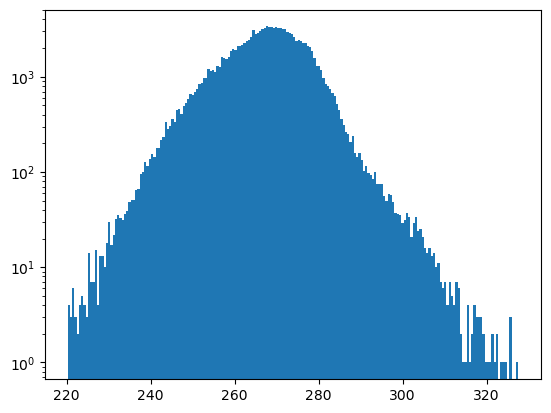

In [54]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

Plot flux and radial velocity

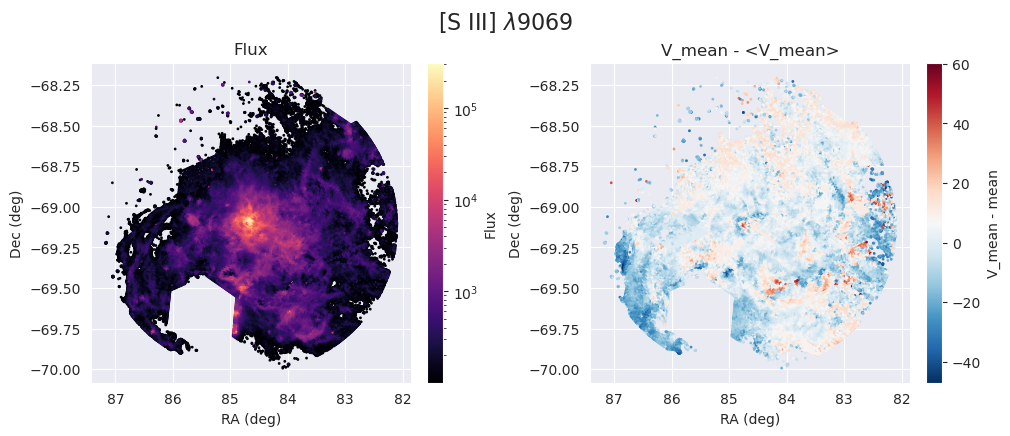

In [15]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

Plot flux and radial velocity in WCS

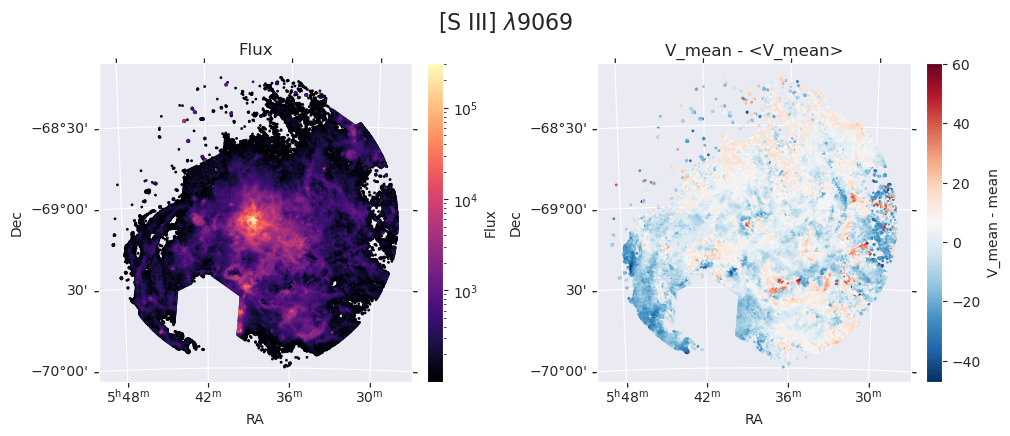

In [16]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_mean - <V_mean>"),
                                          figure_title=plot_label_line)
plt.show()

#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

# Rotation substraction

In [17]:
import lmc_model

In [18]:
df =  line_mask
c = SkyCoord(ra=df["RAdeg"].to_numpy() * u.deg, dec=df["DEdeg"].to_numpy() * u.deg)
c

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.65      , -69.33053993), (84.67528433, -69.325388  ),
     (84.70055662, -69.32023239), ..., (86.38468184, -68.85076607),
     (86.05911519, -68.76011584), (85.86617408, -68.77787917)]>

In [19]:
vmod = lmc_model.vmodel_lmc(c)


In [20]:
df.insert(
    loc=5,
    column="v_mod",
    value=vmod.value,
)


In [21]:
col = df.pop('V_mean')
df.insert(4, 'v_', col)

In [22]:
df.insert(
    loc=2,
    column="V_mean",
    value= df.v_-df.v_mod,
)

In [23]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
count,140085.000000,140085.000000,140085.000000,140085.000000,140085.000000,140085.000000,140085.000000
mean,84.424040,-69.222814,-1.691570,1706.495079,0.949710,267.281537,268.973107
std,1.150702,0.333627,10.324067,8067.735087,0.147699,10.285810,2.372762
min,82.101852,-69.994072,-52.916297,100.004600,0.250000,220.247000,263.695495
25%,83.556624,-69.469577,-7.882799,211.347700,0.845000,261.127700,267.139705
50%,84.349222,-69.231118,-1.324049,410.487200,0.929100,267.979700,269.123459
75%,85.191940,-68.989206,4.701346,978.850200,1.006700,273.941100,270.854521
max,87.176526,-68.203443,61.278920,310989.144300,1.499900,327.567800,276.566558


In [24]:
line_mask = df

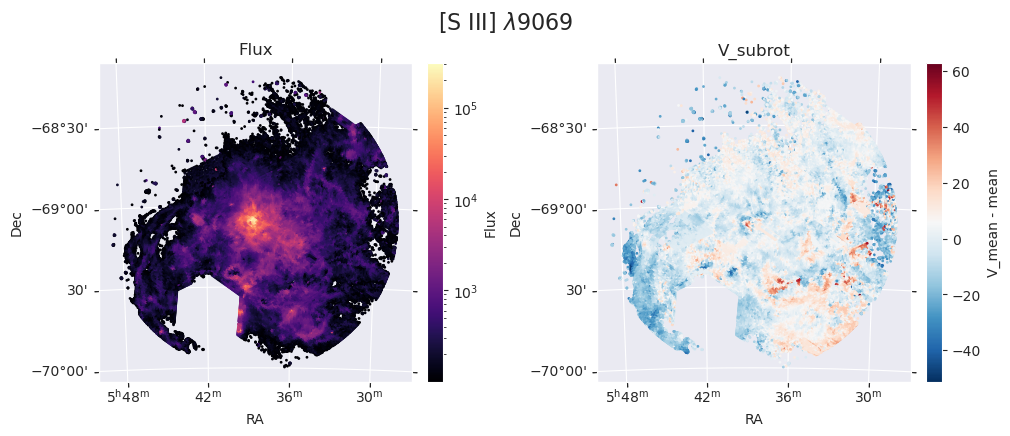

<Figure size 640x480 with 0 Axes>

In [25]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_subrot"),
                                          figure_title=plot_label_line)
plt.show()

plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

# Creating and plotting subfields

In [26]:
radius = 413*u.arcsec
pa = 45 * u.deg # position angle
new_center = centro.directional_offset_by(pa, 2*radius)

Creatings subfields data

In [27]:
import astropy.units as u

r = radius

circles = []

# central circle
circles.append({
    "label": "C0",
    "ring": "center",
    "angle_deg": None,
    "center": centro,
    "ra_deg": centro.ra.deg,
    "dec_deg": centro.dec.deg,
    "radius_arcsec": r.to(u.arcsec).value,
})

# inner ring
d_in = 2 * r
angles_in = [0, 45, 90, 135, 180, 225, 270, 315] * u.deg

for i, pa in enumerate(angles_in, start=1):
    c = centro.directional_offset_by(pa, d_in)
    circles.append({
        "label": f"I{i}",
        "ring": "inner",
        "angle_deg": pa.to(u.deg).value,
        "center": c,
        "ra_deg": c.ra.deg,
        "dec_deg": c.dec.deg,
        "radius_arcsec": r.to(u.arcsec).value,
    })

# middle ring (this was the previous outer ring)
d_mid = 4 * r
angles_mid = [0, 22.5,
              45, 67.5,
              90, 112.5,
              135, #157.5,
              180, 202.5,
              225, 247.5,
              270, 292.5,
              315, 337.5] * u.deg

for i, pa in enumerate(angles_mid, start=1):
    c = centro.directional_offset_by(pa, d_mid)
    circles.append({
        "label": f"M{i}",
        "ring": "middle",
        "angle_deg": pa.to(u.deg).value,
        "center": c,
        "ra_deg": c.ra.deg,
        "dec_deg": c.dec.deg,
        "radius_arcsec": r.to(u.arcsec).value,
    })

# new outer ring: 24 circles
d_out = 6 * r
angles_out = [0, 15, 30, 45, 60, 75,
              90, 105, 120, #135, 150, 165,
              180, 195, 210, 225, 240, 255,
              270, 285, 300, 315, 330, 345] * u.deg

for i, pa in enumerate(angles_out, start=1):
    c = centro.directional_offset_by(pa, d_out)
    circles.append({
        "label": f"O{i}",
        "ring": "outer",
        "angle_deg": pa.to(u.deg).value,
        "center": c,
        "ra_deg": c.ra.deg,
        "dec_deg": c.dec.deg,
        "radius_arcsec": r.to(u.arcsec).value,
    })

Plotting subfields

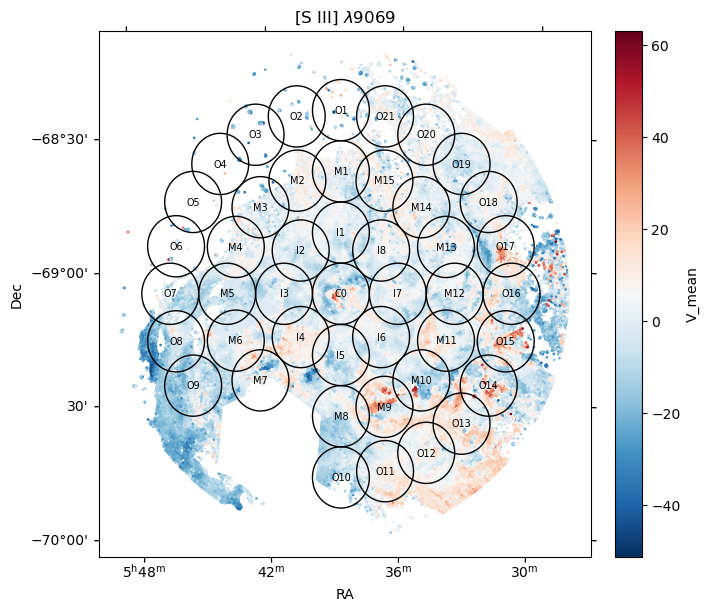

In [28]:
import matplotlib.pyplot as plt
from astropy.visualization.wcsaxes.patches import SphericalCircle

v1 = line_mask["V_mean"] - line_mask["V_mean"].mean()

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

sc = ax.scatter(
    line_mask["RAdeg"],
    line_mask["DEdeg"],
    s=1.0,
    c=v1,
    cmap="RdBu_r",
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title(plot_label_line)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("V_mean")

In [29]:
circles[25]

{'label': 'O2',
 'ring': 'outer',
 'angle_deg': 15.0,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (85.15967931, -68.43441815)>,
 'ra_deg': 85.15967930821463,
 'dec_deg': -68.43441814778524,
 'radius_arcsec': 413.0}

# Data for each circle

In [30]:
coords_all = SkyCoord(
    ra=line_mask["RAdeg"].values * u.deg,
    dec=line_mask["DEdeg"].values * u.deg,
    frame="icrs"
)

In [31]:
regions_data = {}

for circle in circles:
    radius_u = circle["radius_arcsec"] * u.arcsec
    sep = coords_all.separation(circle["center"])
    
    df_circle = line_mask.loc[sep <= radius_u].copy()
    
    regions_data[circle["label"]] = df_circle

# Export subfields

In [32]:

for circle in circles:
    label = circle["label"]
    ring = circle["ring"]
    angle_deg = circle["angle_deg"]
    circle_center = circle["center"]
    circle_radius = circle["radius_arcsec"] * u.arcsec

    # mask data inside this circle
    sep = coords_all.separation(circle_center)
    df_circle = line_mask.loc[sep <= circle_radius].copy()

    # skip empty regions
    if df_circle.empty:
        print(f"Skipping {label}: no data points inside circle.")
        continue

    # compute region-specific parameters
    N = np.sqrt(
        (df_circle.RAdeg.max() - df_circle.RAdeg.min()) *
        (df_circle.DEdeg.max() - df_circle.DEdeg.min())
    ) * pc * 3600

    sig = df_circle["V_mean"].std()

    # define output name
    circle_name_file = f"{name_file}_{label}"
    circle_name_id = f"{name_id}_{label}"

    # table HDU
    t = Table.from_pandas(df_circle.reset_index(drop=True))
    table_hdu = fits.BinTableHDU(t, name=circle_name_file)

    # primary HDU
    primary = fits.PrimaryHDU()
    hdr = primary.header

    hdr["FILE"]      = (circle_name_file, "Fits file name")
    hdr["NAME_ID"]   = (circle_name_id, "pipeline identifier")
    hdr["REG"]       = (region, "Region catalog name")
    hdr["NAME_REG"]  = (name_reg, "Region name")
    hdr["REG_ID"]    = (reg_id, "Region identifier")
    hdr["TYPE_OBJ"]  = (type_obj, "Type object")
    hdr["DIST"]      = (dist, "Distance in parsecs")
    hdr["INSTR"]     = (inst, "Instrument")
    hdr["LINE"]      = (plot_label_line, "Emission line name")
    hdr["LINE_ID"]   = (element, "Emission line identifier")
    hdr["L_REST"]    = (rest_wavelength, "Emission line rest wavelength")
    hdr["SIG"]       = (sig, "Standard deviation vel map")
    hdr["SIG2"]      = (sig**2, "Vel variance map")
    hdr["S0"]        = (s0, "Atmospheric seeing")
    hdr["BOX_SIZE"]  = (N, "Observational box_size")
    hdr["PC"]        = (pc, "parsec conversion")
    hdr["PIX"]       = (pix, "Instrument pixel scale")
    hdr["BINSIZE"]   = (bins, "Spatial binning factor")

    # circle metadata
    hdr["CIRC_ID"]   = (label, "Circle identifier")
    hdr["CIRCRING"]  = (ring, "Circle ring")
    hdr["CIRC_RA"]   = (circle_center.ra.deg, "Circle center RA deg")
    hdr["CIRC_DEC"]  = (circle_center.dec.deg, "Circle center Dec deg")
    hdr["CIRC_RAD"]  = (circle_radius.to(u.arcsec).value, "Circle radius arcsec")
    hdr["AUTHOR"]    = ("J. Garcia-Vazquez", "File creator")

    if angle_deg is not None:
        hdr["CIRC_PA"] = (angle_deg, "Circle position angle deg")

    hdul = fits.HDUList([primary, table_hdu])
    hdul.writeto(f"fits_ready/{circle_name_file}.fits", overwrite=True)

    print(f"Saved: fits_ready/{circle_name_file}.fits  ({len(df_circle)} rows)")

Saved: fits_ready/LVM-30Dor-9069_C0.fits  (5298 rows)
Saved: fits_ready/LVM-30Dor-9069_I1.fits  (5000 rows)
Saved: fits_ready/LVM-30Dor-9069_I2.fits  (4807 rows)
Saved: fits_ready/LVM-30Dor-9069_I3.fits  (5071 rows)
Saved: fits_ready/LVM-30Dor-9069_I4.fits  (4500 rows)
Saved: fits_ready/LVM-30Dor-9069_I5.fits  (4295 rows)
Saved: fits_ready/LVM-30Dor-9069_I6.fits  (4791 rows)
Saved: fits_ready/LVM-30Dor-9069_I7.fits  (4602 rows)
Saved: fits_ready/LVM-30Dor-9069_I8.fits  (4416 rows)
Saved: fits_ready/LVM-30Dor-9069_M1.fits  (1868 rows)
Saved: fits_ready/LVM-30Dor-9069_M2.fits  (1585 rows)
Saved: fits_ready/LVM-30Dor-9069_M3.fits  (597 rows)
Saved: fits_ready/LVM-30Dor-9069_M4.fits  (1884 rows)
Saved: fits_ready/LVM-30Dor-9069_M5.fits  (3540 rows)
Saved: fits_ready/LVM-30Dor-9069_M6.fits  (3818 rows)
Saved: fits_ready/LVM-30Dor-9069_M7.fits  (2240 rows)
Saved: fits_ready/LVM-30Dor-9069_M8.fits  (3945 rows)
Saved: fits_ready/LVM-30Dor-9069_M9.fits  (4164 rows)
Saved: fits_ready/LVM-30Dor-9

In [33]:
import pandas as pd

circles_df = pd.DataFrame([
    {
        "label": c["label"],
        "ring": c["ring"],
        "angle_deg": c["angle_deg"],
        "ra_deg": c["ra_deg"],
        "dec_deg": c["dec_deg"],
        "radius_arcsec": c["radius_arcsec"],
    }
    for c in circles
])

circles_df.to_csv("fits_ready/circle_catalog.csv", index=False)

In [34]:
export_names = [f"{name_file}_{circle['label']}" for circle in circles]

with open("fits_ready/filelist_circles.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(export_names) + "\n")

In [35]:
export_names = [f"{name_file}_{circle['label']}" for circle in circles]

with open("fits_ready/filelist.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(export_names) + "\n")

In [36]:
xxx

NameError: name 'xxx' is not defined

# Export

In [ ]:
N = np.sqrt((line_mask.RAdeg.max()-line_mask.RAdeg.min())*(line_mask.DEdeg.max()-line_mask.DEdeg.min())) * pc * 3600
sig       = line_mask['V_mean'].std()

In [ ]:
t         = Table.from_pandas(line_mask.reset_index(drop=True))
table_hdu = fits.BinTableHDU(t, name=name_file)

In [ ]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (region, "Region catalog name")
primary.header["NAME_REG"]   = (name_reg, "Region name")
primary.header["REG_ID"]     = (reg_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (type_obj, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (plot_label_line, "Emission line name")
primary.header["LINE_ID"]    = (element, "Emission line identifier")
primary.header["L_REST"]= (rest_wavelength, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N, "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix, "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [ ]:
hdul = fits.HDUList([primary, table_hdu])
hdul.writeto("fits_ready/" + name_file + ".fits", overwrite=True)

In [ ]:
with fits.open("fits_ready/" + name_file + ".fits") as hdul:
    hdul.info()